# Reviews EDA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [3]:
reviews = pd.read_csv("../04_Feature_Engineering/Output/order_reviews_features.csv")

In [4]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_response_time_days,has_review_comment,positive_review_flag
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,0.907627,0,1
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,1.128623,0,1
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,1.608611,0,1
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,0.918125,1,1
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,1.435336,1,1


In [5]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   review_id                  99224 non-null  object 
 1   order_id                   99224 non-null  object 
 2   review_score               99224 non-null  int64  
 3   review_comment_title       11568 non-null  object 
 4   review_comment_message     40977 non-null  object 
 5   review_creation_date       99224 non-null  object 
 6   review_answer_timestamp    99224 non-null  object 
 7   review_response_time_days  99224 non-null  float64
 8   has_review_comment         99224 non-null  int64  
 9   positive_review_flag       99224 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 7.6+ MB


In [6]:
reviews.describe(include="all")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_response_time_days,has_review_comment,positive_review_flag
count,99224,99224,99224.000000,11568,40977,99224,99224,99224.000000,99224.000000,99224.000000
unique,98410,98673,NaN,4527,36159,636,98248,NaN,NaN,NaN
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05,NaN,NaN,NaN
freq,3,3,NaN,423,230,463,4,NaN,NaN,NaN
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN,3.148993,0.412975,0.770680
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN,9.890049,0.492371,0.420397
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.089225,0.000000,0.000000
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,1.004870,0.000000,1.000000
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,1.674948,0.000000,1.000000
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,3.103565,1.000000,1.000000


In [7]:
reviews.isnull().sum()

review_id                        0
order_id                         0
review_score                     0
review_comment_title         87656
review_comment_message       58247
review_creation_date             0
review_answer_timestamp          0
review_response_time_days        0
has_review_comment               0
positive_review_flag             0
dtype: int64

In [8]:
reviews.duplicated().sum()

0

## 1. Customer Satisfaction Analysis

In [9]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [11]:
review_score_pct = (
    reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .reset_index()
)

review_score_pct.columns = ["review_score", "percentage"]

review_score_pct

,review_score,percentage
0,1,11.51
1,2,3.18
2,3,8.24
3,4,19.29
4,5,57.78


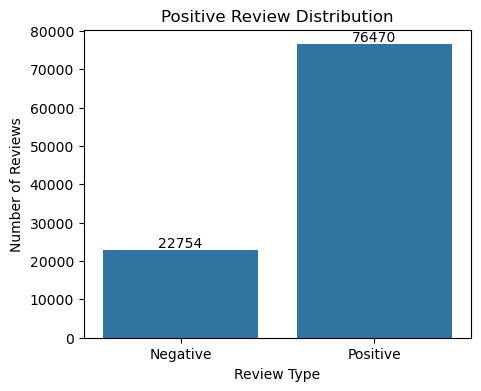

In [13]:
#Here positive review is 4 and 5 star ,rest is negative review
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=reviews,
    x="positive_review_flag"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks([0,1], ["Negative", "Positive"])

plt.title("Positive Review Distribution")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")

plt.show()

## 2. Review Response Time

In [15]:
# Helper Function 
def analyze_numeric_feature(df, column, bins=50):
    """
    Performs basic EDA for a numeric feature.
    """

    print("=" * 60)
    print(f"EDA for: {column}")
    print("=" * 60)

    # Summary Statistics
    print("\nSummary Statistics\n")
    print(df[column].describe())

    # Missing Values
    print("\nMissing Values\n")
    print(df[column].isnull().sum())

    # Histogram
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,

        x=column,
        bins=bins,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 2))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Boxplot of {column}")


    plt.show()

    # Largest Values
    print("\nTop 10 Largest Values\n")
    print(df[column].nlargest(10))

    # Smallest Values
    print("\nTop 10 Smallest Values\n")
    print(df[column].nsmallest(10))

EDA for: review_response_time_days

Summary Statistics

count    99224.000000
mean         3.148993
std          9.890049
min          0.089225
25%          1.004870
50%          1.674948
75%          3.103565
max        518.699213
Name: review_response_time_days, dtype: float64

Missing Values

0


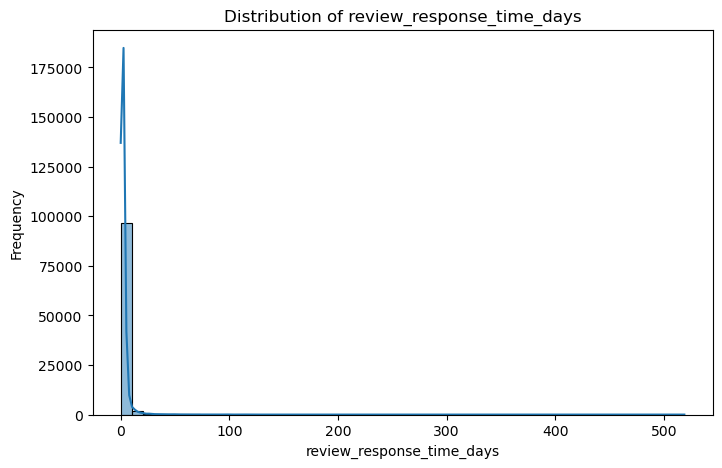

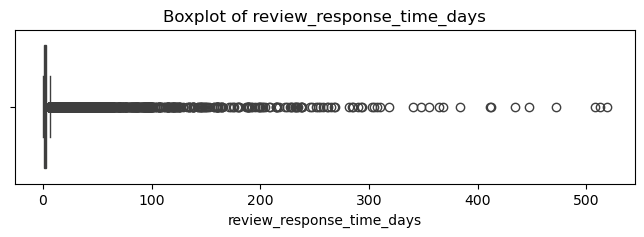


Top 10 Largest Values

41620    518.699213
66672    512.658067
22059    508.066771
8758     471.680475
13920    446.869144
90778    433.979826
50957    412.521007
39291    411.443900
56047    383.430683
8441     367.681898
Name: review_response_time_days, dtype: float64

Top 10 Smallest Values

49291    0.089225
83108    0.100278
6676     0.100914
13330    0.101539
95333    0.102280
60587    0.102963
48566    0.103333
94966    0.103426
48104    0.104306
40833    0.105139
Name: review_response_time_days, dtype: float64


In [16]:
analyze_numeric_feature(
    reviews,
    "review_response_time_days"
)

## Overall Business Insights

**Insight 1**
The high proportion of positive reviews indicates strong overall customer satisfaction, which can contribute to improved customer retention and repeat purchases.

**Insight 2**
Negative reviews, although less frequent, should be analyzed further to identify recurring issues related to delivery performance, product quality, or seller service.

**Insight 3**
Since customers typically leave reviews within a few days of delivery, Olist can monitor review trends shortly after order completion to identify operational issues and respond quickly.

**Insight 4**
Review data should be integrated with order, seller, payment, and delivery information during SQL Analytics to identify the factors that most strongly influence customer satisfaction.